# Deep Neural Networks with PyTorch

## Scientific Python for Engineers Workshop - Hour 3

**Author:** Dilip Kalagotla  
**Contact:** dilip.kalagotla@gmail.com

## Learning Objectives

- Understand what neural networks are
- Learn the basic components of a DNN
- Train models on different datasets
- Validate and evaluate model performance

---

## Introduction to Neural Networks

A **neural network** is a computational model inspired by biological neural networks. It consists of:

1. **Input Layer**: Receives the raw data
2. **Hidden Layers**: Process the data through weighted connections
3. **Output Layer**: Produces the prediction

### Key Concepts

- **Weights**: Parameters learned during training
- **Activation Functions**: Non-linear transformations (tanh, ReLU, sigmoid)
- **Loss Function**: Measures how wrong the predictions are
- **Optimizer**: Algorithm to update weights (SGD, Adam)
- **Epoch**: One complete pass through the training data

### Training Process

1. **Forward Pass**: Input → Predictions
2. **Calculate Loss**: Compare predictions to true values
3. **Backward Pass**: Calculate gradients
4. **Update Weights**: Adjust parameters to reduce loss
5. **Repeat** for many epochs

---
## Setup

First, let's import our simple_dnns package and other necessary libraries.

In [1]:
# Add parent directory to path for imports
import sys
sys.path.insert(0, '.')

# Import the simple_dnns package
from simple_dnns import Univariate, Bivariate, SimpleData

# Standard imports
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Available Dataset Classes

The `simple_dnns` package provides several dataset classes:

| Class | Input Dim | Output Dim | Description |
|-------|-----------|------------|-------------|
| `Univariate` | 1 | 1 | sin(x) + cos(x) |
| `Bivariate` | 2 | 1 | sin(x₁) + cos(x₂) |
| `SimpleData` | 1 | 1 | Noisy linear + nonlinear function |
| `NoiseData` | 5 | 1 | Real airfoil noise data |

---
## Understanding the Class API

Before we dive into examples, let's understand how to work with these classes.

### Quick OOP Refresher

- **Class**: A blueprint/template for creating objects (e.g., `Univariate`)
- **Object/Instance**: A specific model created from the class (e.g., `model1 = Univariate(...)`)
- **Attributes**: Data stored in the object (e.g., `model1.layers`, `model1.learning_rate`)
- **Methods**: Functions that operate on the object (e.g., `model1.train()`, `model1.validation()`)

### Class Structure

All dataset classes (`Univariate`, `Bivariate`, `SimpleData`, `NoiseData`) follow the same pattern:

**Constructor Parameters:**

```python
Univariate(
    layers=[1, 5, 10, 5, 1],  # Network architecture: [input, hidden..., output]
    p_train=0.7,              # Fraction of data for training (rest for validation)
    learning_rate=0.01,       # Step size for weight updates
    epochs=100,               # Number of training iterations
    momentum=0.9              # SGD momentum (helps escape local minima)
)
```

**Key Attributes (available after calling `set_parameters()`):**

| Attribute | Type | Description |
|-----------|------|-------------|
| `layers` | list | Network architecture |
| `learning_rate` | float | Current learning rate |
| `epochs` | int | Number of training epochs |
| `data_set` | Data | The dataset object (has `.x`, `.y`, `.plot()`) |
| `net` | Net | The PyTorch neural network |
| `optimizer` | SGD | The optimizer |
| `criterion` | MSELoss | The loss function |

**Methods:**

| Method | Purpose |
|--------|---------|
| `set_parameters()` | **Must call first!** Initializes network, optimizer, and data loaders |
| `train(plot=True, plot_at=10)` | Train the model with optional live visualization |
| `validation()` | Evaluate performance on held-out validation data |
| `restart()` | Reset network weights to random values |
| `continue_train(filename)` | Load a saved checkpoint and resume training |

In [ ]:
# Try It: Explore a Model Object
# Let's create a model and inspect its attributes

demo_model = Univariate(layers=[1, 5, 5, 1], epochs=50, learning_rate=0.02)
demo_model.set_parameters()

print("=== Exploring the Model Object ===\n")

# Configuration attributes
print("Configuration:")
print(f"  layers:        {demo_model.layers}")
print(f"  learning_rate: {demo_model.learning_rate}")
print(f"  epochs:        {demo_model.epochs}")
print(f"  momentum:      {demo_model.momentum}")
print(f"  p_train:       {demo_model.p_train}")

# The neural network
print(f"\nNeural Network Architecture:")
print(f"  {demo_model.net}")

# The dataset
print(f"\nDataset Info:")
print(f"  Total samples: {len(demo_model.data_set)}")
print(f"  Input shape:   {demo_model.data_set.x.shape}")
print(f"  Output shape:  {demo_model.data_set.y.shape}")

# The loss function and optimizer
print(f"\nTraining Components:")
print(f"  Loss function: {demo_model.criterion}")
print(f"  Optimizer:     {type(demo_model.optimizer).__name__}")

---
## Example 1: Univariate Regression

Let's start with the simplest case: learning a 1D function.

**Target Function:** y = sin(x) + cos(x)

In [2]:
# Create a Univariate model with custom parameters
model1 = Univariate(
    layers=[1, 5, 10, 5, 1],  # Network architecture
    epochs=100,              # Number of training epochs
    learning_rate=0.01,      # Step size for gradient descent
    momentum=0.9,            # Momentum for SGD optimizer
    p_train=0.7              # Fraction of data for training
)

# Initialize the model parameters
model1.set_parameters()

print("Model created!")
print(f"Network architecture: {model1.layers}")

Model created!
Network architecture: [1, 5, 10, 5, 1]


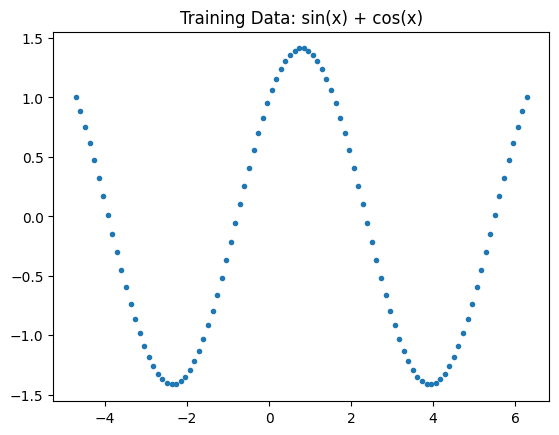

In [3]:
# Visualize the training data
model1.data_set.plot(title='Training Data: sin(x) + cos(x)')

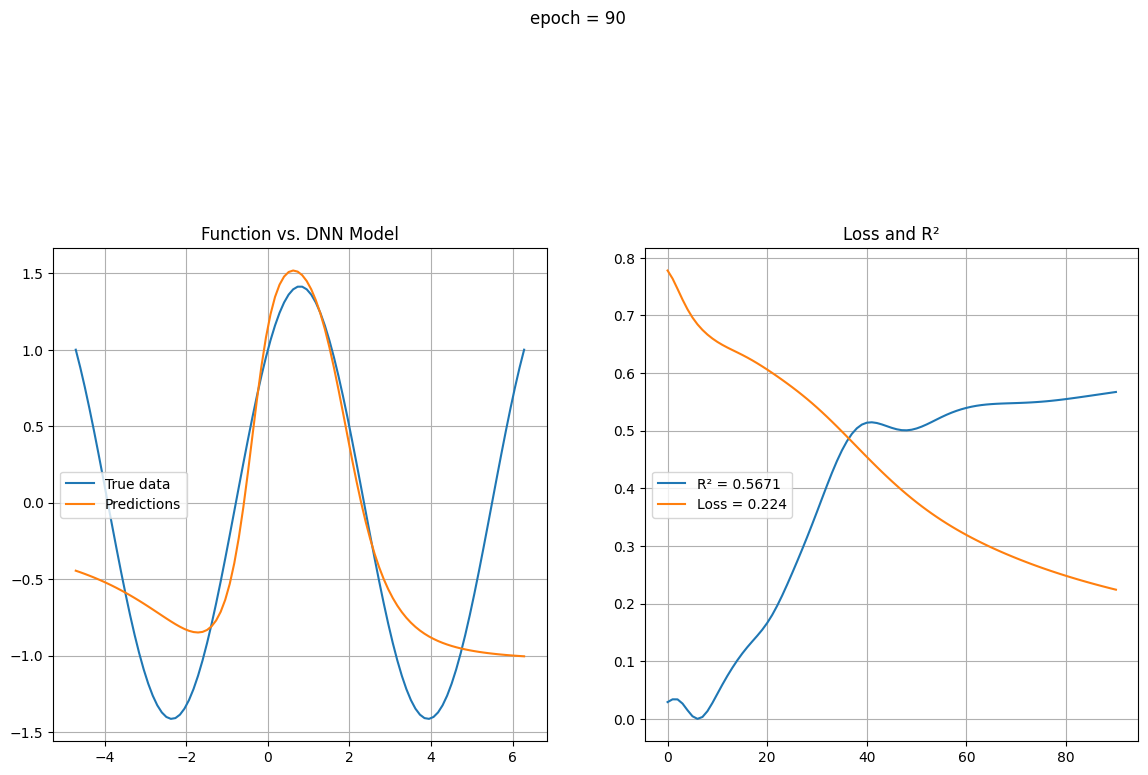

In [4]:
# Train the model
# Note: Set plot_at to a higher number if you want fewer plot updates
model1.train(plot=True, plot_at=10)

Validation error for the trained model = 0.5008935332298279


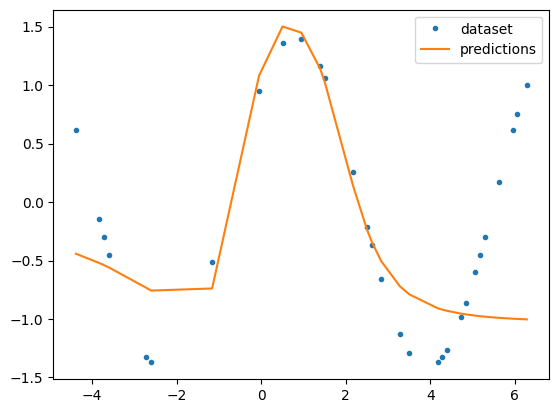

In [5]:
# Validate the model on held-out data
model1.validation()

### Exercise 1: Experiment with Parameters

Try changing the following and observe the effects:
- Network architecture (layers)
- Learning rate
- Number of epochs

**Questions to consider:**
- What happens with too few neurons?
- What happens with too high a learning rate?
- How does training time relate to network size?

In [6]:
# Your experimentation code here
# model_exp = Univariate(layers=[1, 3, 1], epochs=200, learning_rate=0.001)
# model_exp.set_parameters()
# model_exp.train(plot=True, plot_at=20)

---
## Example 2: Bivariate Regression (3D Surface)

Now let's learn a function with two inputs:

**Target Function:** z = sin(x) + cos(y)

In [7]:
# Create a Bivariate model
model2 = Bivariate(
    layers=[2, 20, 20, 1],   # Note: input is 2D now
    epochs=50,
    learning_rate=0.1,
    momentum=0.7
)

model2.set_parameters()
print(f"Network architecture: {model2.layers}")

Network architecture: [2, 20, 20, 1]


c:\Users\kalagotla\OneDrive - Florida State University\Documents\Scripts\dc-qc-sci-python\.venv\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


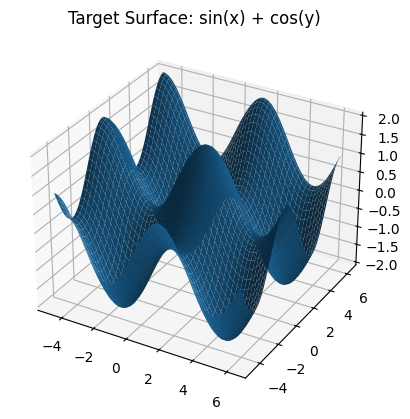

In [8]:
# Visualize the target surface
model2.data_set.plot(title='Target Surface: sin(x) + cos(y)')

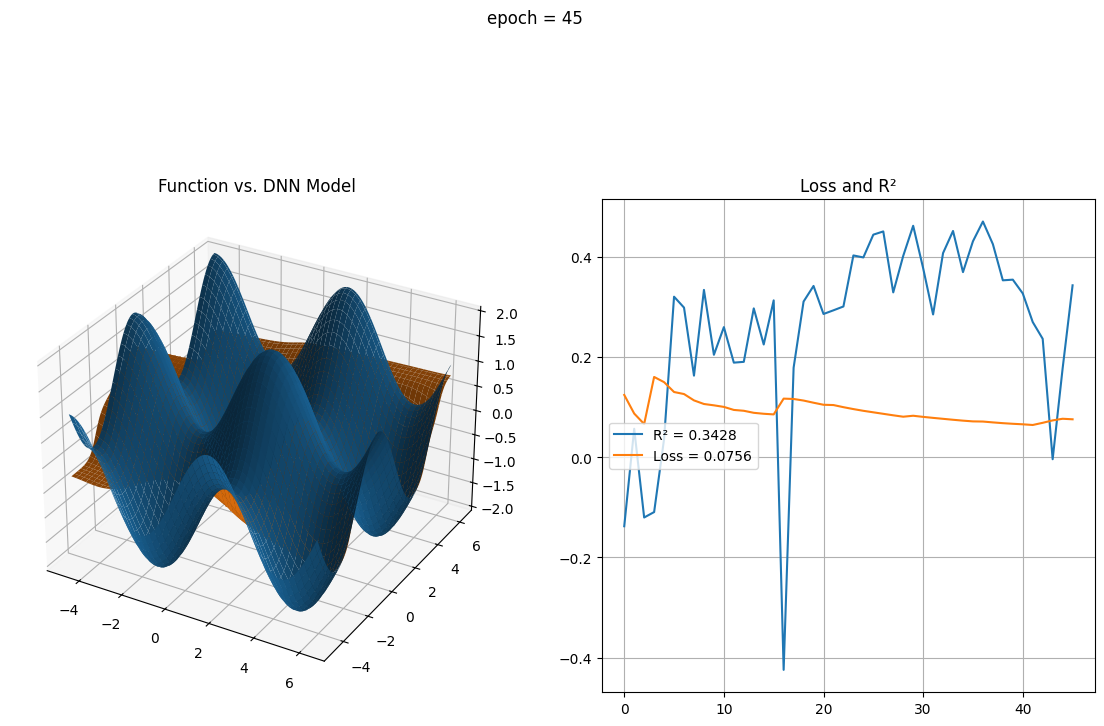

In [9]:
# Train the model
model2.train(plot=True, plot_at=5)

Validation error for the trained model = 0.6728135943412781


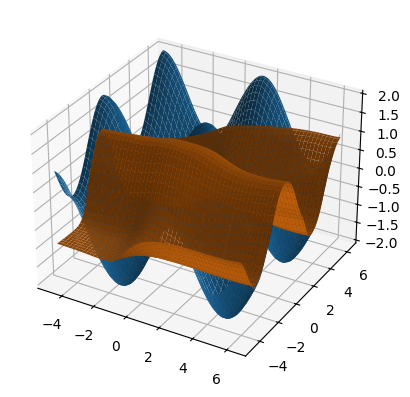

In [10]:
# Validate
model2.validation()

### Exercise 2: Effects of Network Architecture

Now that you've seen both univariate and bivariate examples, let's explore how network architecture affects learning.

**Tasks:**
1. Try training a univariate model with only **1 hidden layer** (e.g., `layers=[1, 5, 1]`)
2. Try training with a **very deep network** (e.g., `layers=[1, 3, 3, 3, 3, 3, 1]`)
3. Compare the training curves - which converges faster?

**Questions to consider:**
- Does adding more layers always improve performance?
- What happens if the hidden layer is too small to capture the function complexity?
- How does network depth affect training time?

In [11]:
# Exercise 2: Experiment with network architecture
# Uncomment and modify the code below to explore

# Shallow network (1 hidden layer)
# model_shallow = Univariate(layers=[1, 10, 1], epochs=100, learning_rate=0.01)
# model_shallow.set_parameters()
# model_shallow.train(plot=True, plot_at=10)

# Deep network (5 hidden layers)
# model_deep = Univariate(layers=[1, 3, 3, 3, 3, 3, 1], epochs=100, learning_rate=0.01)
# model_deep.set_parameters()
# model_deep.train(plot=True, plot_at=10)

---
## Example 3: Noisy Data Regression

Real-world data is noisy. Let's see how well the network can learn the underlying pattern.

In [12]:
# Create a SimpleData model
model3 = SimpleData(
    layers=[1, 10, 20, 20, 10, 1],
    epochs=150,
    learning_rate=0.01,
    momentum=0.7,
    p_train=0.7
)

model3.set_parameters()
print(f"Network architecture: {model3.layers}")

Network architecture: [1, 10, 20, 20, 10, 1]


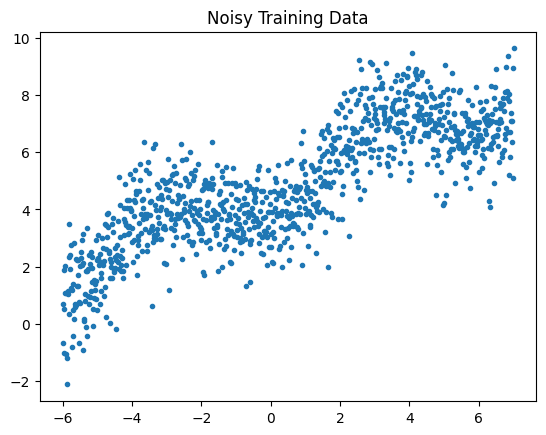

In [13]:
# Visualize the noisy data
model3.data_set.plot(title='Noisy Training Data')

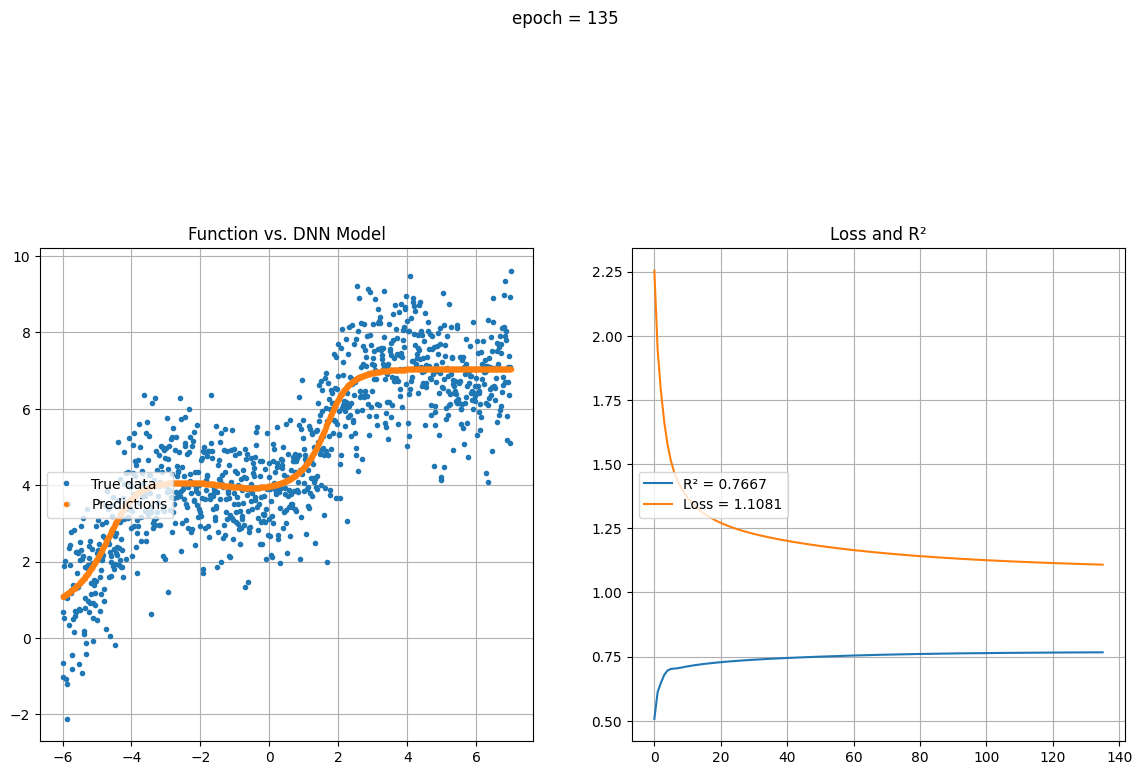

In [14]:
# Train
model3.train(plot=True, plot_at=15)

Validation error for the trained model = 0.9438820481300354
Validation error against real data: 0.056162454187870026


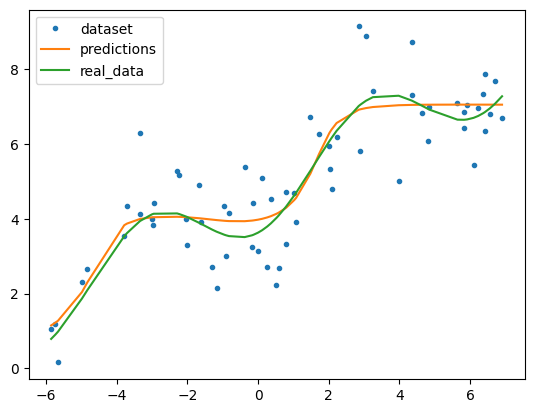

In [15]:
# Validate against actual data and the true underlying function
model3.validation_real_data()

### Exercise 3: Learning Rate Exploration

The learning rate is one of the most important hyperparameters. Too high and training becomes unstable; too low and training is very slow.

**Tasks:**
1. Train a univariate model with a **very high learning rate** (e.g., `learning_rate=1.0`)
2. Train the same model with a **very low learning rate** (e.g., `learning_rate=0.0001`)
3. Find a learning rate that converges well within 100 epochs

**Bonus Challenge:** Try using the `SimpleData` class with different learning rates. Does the noisy data require different hyperparameters?

In [16]:
# Exercise 3: Experiment with learning rates
# Uncomment and modify the code below

# High learning rate - watch for instability!
# model_high_lr = Univariate(layers=[1, 5, 10, 5, 1], epochs=50, learning_rate=1.0)
# model_high_lr.set_parameters()
# model_high_lr.train(plot=True, plot_at=5)

# Low learning rate - much slower convergence
# model_low_lr = Univariate(layers=[1, 5, 10, 5, 1], epochs=100, learning_rate=0.0001)
# model_low_lr.set_parameters()
# model_low_lr.train(plot=True, plot_at=10)

---
## Key Parameters Reference

| Parameter | Description | Typical Values |
|-----------|-------------|----------------|
| `layers` | Network architecture | [input, hidden..., output] |
| `epochs` | Training iterations | 50-500 |
| `learning_rate` | Step size | 0.001-0.1 |
| `momentum` | SGD momentum | 0.7-0.99 |
| `p_train` | Training data fraction | 0.7-0.8 |

## Key Methods

| Method | Description |
|--------|-------------|
| `set_parameters()` | Initialize model |
| `train()` | Train the model |
| `restart()` | Reset weights |
| `continue_train()` | Load checkpoint and continue |
| `validation()` | Evaluate on validation set |

---
## Saving and Loading Models

Models are automatically saved during training. You can continue training from a checkpoint.

In [17]:
# Models are saved to the models/ directory
# To continue training:
# model1.continue_train(filename='../models/1var_model.tar')
# model1.train(plot=True, plot_at=10)

---
## Summary

You've learned:

1. **What neural networks are**: Computational models with layers of neurons
2. **How to configure them**: Layers, learning rate, epochs, momentum
3. **How to train them**: Forward pass, loss calculation, backpropagation
4. **How to validate them**: Hold out data and measure error

### Tips for Success

- Start with a simple architecture and add complexity if needed
- If loss is not decreasing, try lowering the learning rate
- If training is too slow, try increasing the learning rate
- Watch for overfitting: good training loss but poor validation
- Experiment! ML is often empirical.

---
## Exercise: Real-World Airfoil Noise Prediction

Now let's apply what we've learned to a real-world dataset!

### About the Dataset

The **NASA Airfoil Self-Noise Dataset** contains aerodynamic and acoustic test results from wind tunnel experiments. The goal is to predict the **Scaled Sound Pressure Level (SPL)** - the noise level produced by different airfoil configurations.

**Input Features (5):**
| Feature | Description | Unit |
|---------|-------------|------|
| Frequency | Sound frequency | Hz |
| Angle of Attack | Airfoil angle | degrees |
| Chord Length | Airfoil chord | meters |
| Free-Stream Velocity | Wind speed | m/s |
| Suction Side Displacement Thickness | Boundary layer thickness | meters |

**Output (1):**
- **Scaled Sound Pressure Level (SPL)** in decibels

The dataset contains **1503 observations** from various airfoil blade section tests.

### Your Task

Use the `NoiseData` class to:
1. Create and configure a neural network
2. Visualize the data relationships
3. Train the model
4. Evaluate its performance

In [18]:
# Import the NoiseData class
from simple_dnns import NoiseData

# Create the model with a network architecture suited for 5 inputs
# The default architecture is [5, 20, 50, 50, 20, 1]
noise_model = NoiseData(
    layers=[5, 20, 50, 50, 20, 1],  # 5 inputs -> hidden layers -> 1 output
    epochs=500,
    learning_rate=0.01,
    momentum=0.9
)

# Set up the model with the airfoil dataset
noise_model.set_parameters(data_path='data/airfoil_self_noise.dat')

### Visualize the Dataset

The `NoiseData` class includes a built-in visualization method using seaborn's pairplot. This helps you understand the relationships between input features and the target variable.

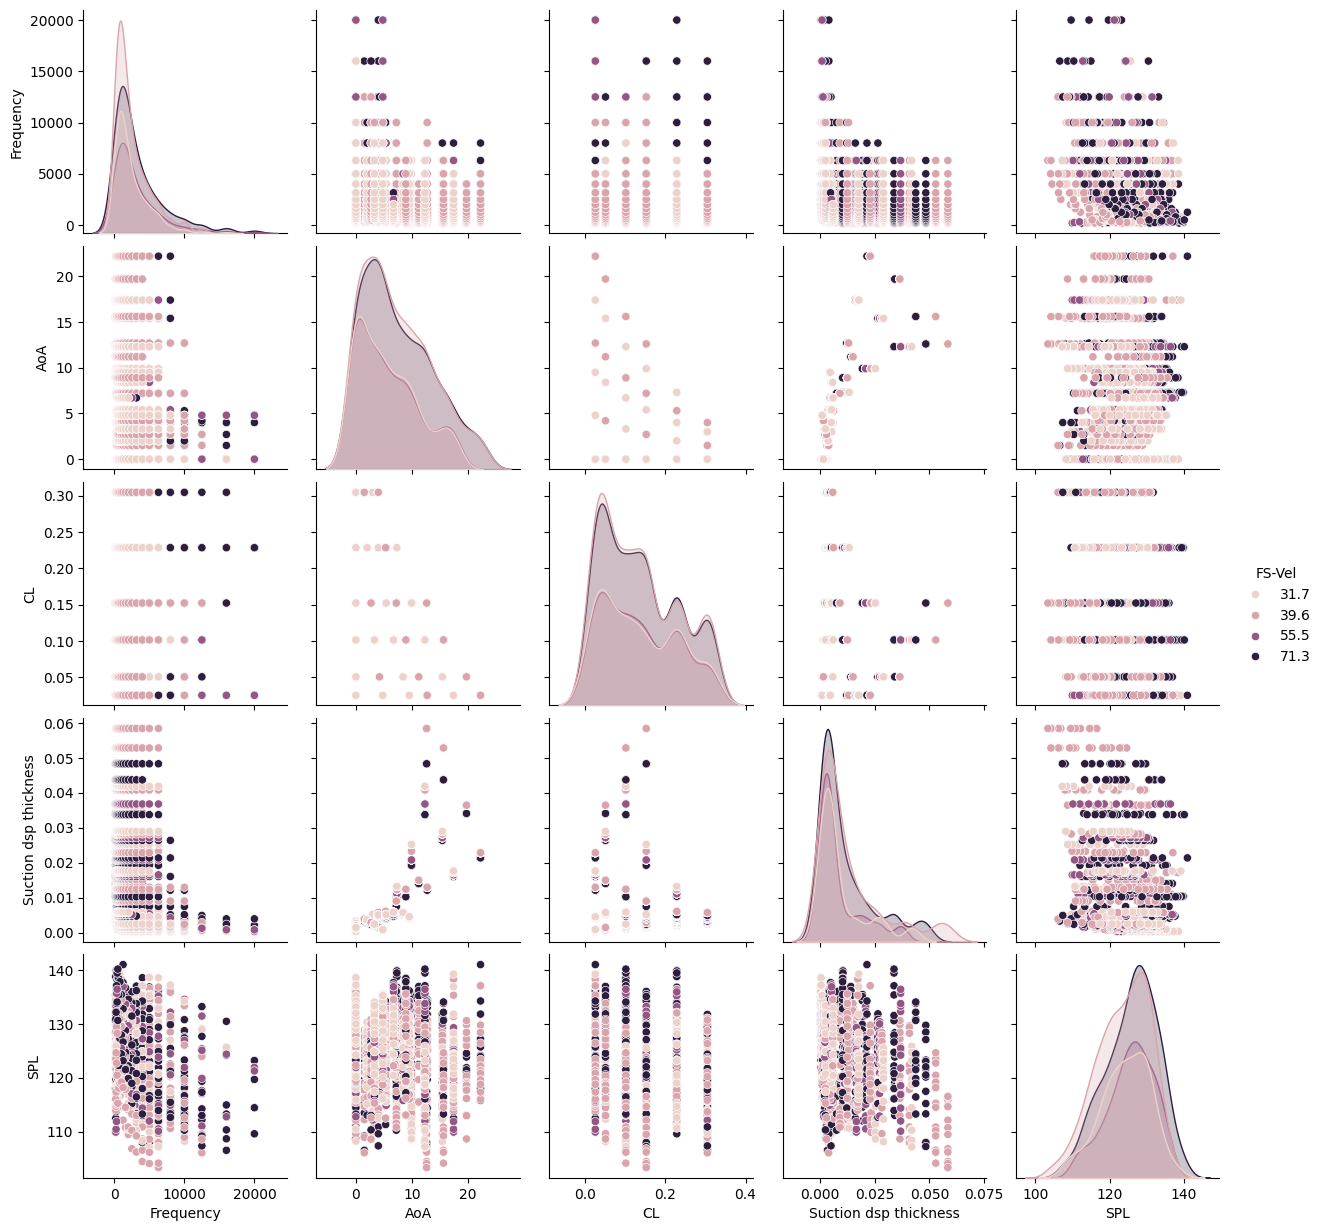

In [19]:
# Visualize relationships in the data
# This creates a pairplot showing correlations between all variables
noise_model.data.plot()

### Train the Model

Train the neural network on the airfoil noise data. Watch the loss decrease over epochs!

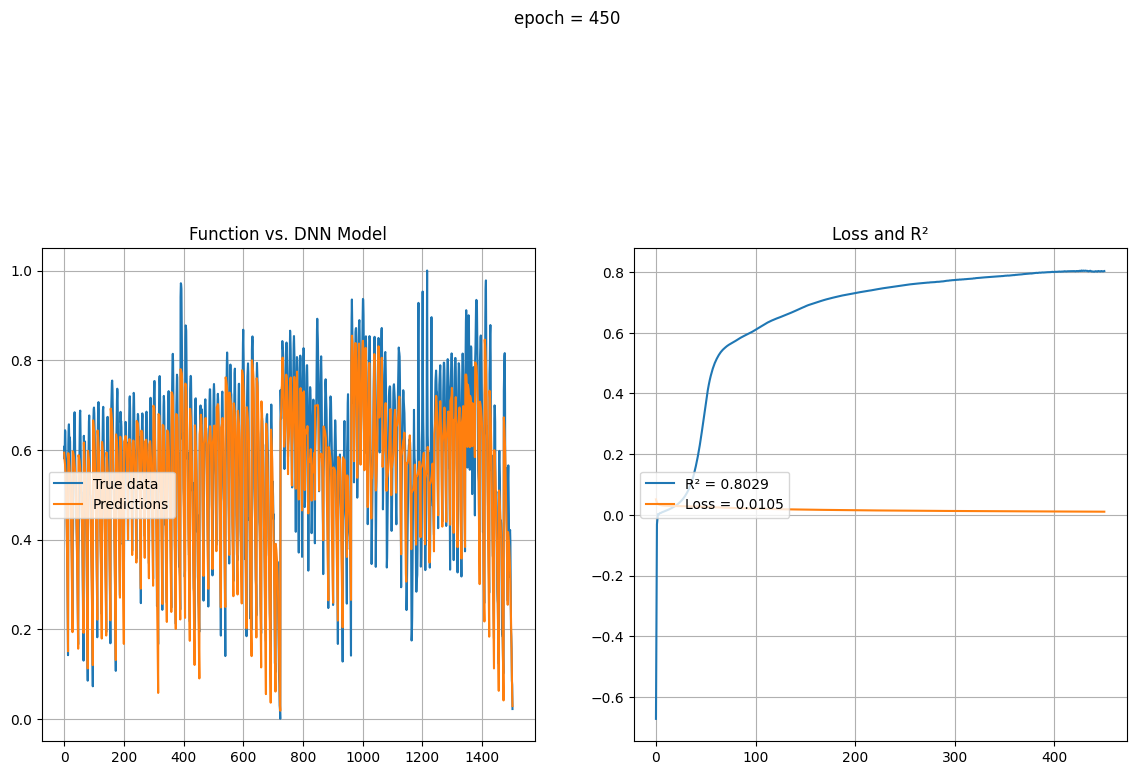

In [20]:
# Train the model with live plotting
# plot=True shows the loss curve, plot_at updates every N epochs
noise_model.train(plot=True, plot_at=50)

### Validate the Model

Check how well the model performs on data it hasn't seen during training.

Validation error for the trained model = 0.005624955520033836


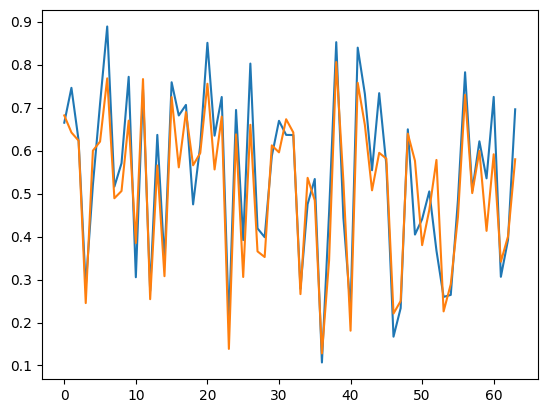

In [21]:
# Validate the model on held-out data
noise_model.validation()

### Experiment Further!

Try modifying the model to improve performance:

1. **Change the architecture**: Try different layer sizes (e.g., `[5, 32, 64, 32, 1]`)
2. **Adjust hyperparameters**: Experiment with `learning_rate` (0.001-0.1) and `momentum` (0.5-0.99)
3. **Train longer**: Increase `epochs` to 1000 or more
4. **Continue training**: Use `noise_model.continue_train()` to resume from a checkpoint

```python
# Example: Create a deeper network
noise_model2 = NoiseData(
    layers=[5, 32, 64, 64, 32, 1],
    epochs=1000,
    learning_rate=0.005,
    momentum=0.95
)
noise_model2.set_parameters(data_path='data/airfoil_self_noise.dat')
noise_model2.train(plot=True, plot_at=100)
```

---
## Next Steps: ML Challenge

Ready to apply these skills to a real-world problem?

Check out the **ML Challenge** information in `ml_challenge_info.md`!

We'll be hosting a workshop series focused on solving the [Fluids Challenge](https://fluids-challenge.engin.umich.edu/) using machine learning techniques.